# Notebook for preprocessing CTE ocean fluxes

In [1]:
import numpy as np
import pandas as pd
import xarray as xr
import os
from global_land_mask import globe

import matplotlib.pyplot as plt
import matplotlib as mpl
import cartopy.crs as ccrs



In [2]:
def select_area(aoi, ds):
    # Determine the dimension names for latitude and longitude
    lat_name = 'lat' if 'lat' in ds.dims else 'latitude'
    lon_name = 'lon' if 'lon' in ds.dims else 'longitude'
    
    # Select the area based on the area of interest
    area_subset = ds.sel({lon_name: slice(aoi[0], aoi[1]),
                          lat_name: slice(aoi[2], aoi[3])})
    return area_subset

def extract_period(fname):
    period= int(fname[-9:-3])
    return period

def extract_year(fname):
    year = int(fname[-9:-5])
    return year

In [3]:
DATA_PATH = "/home/pietaril/Documents/data/CTE_ocean_fluxes/"

filenames = [os.path.join(DATA_PATH,f) for f in os.listdir(DATA_PATH) if f.endswith(".nc")]

ds = xr.open_dataset(filenames[0])
ds


<xarray.Dataset>
Dimensions:    (time: 672, longitude: 250, latitude: 390)
Coordinates:
  * time       (time) datetime64[ns] 2019-02-01 ... 2019-02-28T23:00:00
  * longitude  (longitude) float64 -14.9 -14.7 -14.5 -14.3 ... 34.5 34.7 34.9
  * latitude   (latitude) float64 33.05 33.15 33.25 33.35 ... 71.75 71.85 71.95
Data variables:
    ocean      (time, latitude, longitude) float32 ...
Attributes: (12/19)
    CDI:                        Climate Data Interface version 1.9.9 (https:/...
    Conventions:                CF-1.8
    URL:                        http://carbontracker.wur.nl
    disclaimer:                 This data belongs to the CarbonTracker project
    CDO:                        Climate Data Operators version 1.9.9 (https:/...
    source:                     CTE-HR 1.0. Created using the code from https...
    ...                         ...
    geospatial_lat_resolution:  0.1 degree
    geospatial_lon_resolution:  0.2 degree
    keywords:                   carbon flux
    license:                    CC-BY-4.0
    nominal_resolution:         0.1x0.2 degree
    comment:                    Hourly ocean fluxes, based on a climatology o...

# Check time unit

In [4]:
import netCDF4 as nc

data_nc = nc.Dataset(filenames[0], 'r')
data_nc.variables["ocean"][:]

masked_array(
  data=[[[-9.30314954e-08, -9.34890849e-08, -9.31449762e-08, ...,
          -1.72693522e-08, -1.40798351e-08, -9.88285365e-09],
         [-1.00550665e-07, -1.00463964e-07, -9.84629338e-08, ...,
          -2.01627142e-08, -1.60973848e-08, -1.18232464e-08],
         [-1.08546459e-07, -1.07879842e-07, -1.04089217e-07, ...,
          -2.36012507e-08, -1.86202573e-08, -1.40050851e-08],
         ...,
         [-2.38469852e-07, -2.44718905e-07, -2.50605012e-07, ...,
          -1.98806745e-07, -1.97352605e-07, -1.95876240e-07],
         [-2.37030591e-07, -2.43819443e-07, -2.49954496e-07, ...,
          -1.99895794e-07, -1.98466651e-07, -1.96939197e-07],
         [-2.35480769e-07, -2.42793959e-07, -2.49195040e-07, ...,
          -2.00913902e-07, -1.99541105e-07, -1.97982473e-07]],

        [[-1.15585209e-07, -1.06885501e-07, -1.02919877e-07, ...,
          -1.91984011e-08, -1.72857799e-08, -1.30928983e-08],
         [-1.17944438e-07, -1.11490202e-07, -1.08178121e-07, ...,
        

# Convert from mol/m2/s to kg/m2/hr

In [50]:
aoi = [-12, 35, 35, 72]

DATA_PATH = "/home/pietaril/Documents/data/CTE_ocean_fluxes/raw_data/"
OUT_PATH = "/home/pietaril/Documents/data/CTE_ocean_fluxes/domain_-12_35_35_72/coarse_kg_m-2_hr-1/"

#sort the filenames by time so no need to sort later
fnames = [os.path.join(DATA_PATH,f) for f in os.listdir(DATA_PATH) if f.endswith(".nc")]
df_filenames = pd.DataFrame({'filename': fnames})
df_filenames['period'] = df_filenames['filename'].apply(extract_period)
df_filenames['year'] = df_filenames['filename'].apply(extract_year)
df_filenames = df_filenames.sort_values('period').reset_index(drop=True)


# Open all input files for the year
for year in range(2018, 2022):
    files_1year = df_filenames[df_filenames['year']==year]['filename'].to_list()
    assert len(files_1year)==12
    datasets = [xr.open_dataset(file) for file in files_1year]
    #concatenate the files to a single dataset along time dimension
    ds_1year = xr.concat(datasets, dim="time")

    #select domain
    ds_1year = select_area(aoi, ds_1year)

    #convert fluxes to float64
    ds_1year["ocean"] = ds_1year["ocean"].astype("float64")


    # unit conversion from mol m-2 s-1 to kg m-2 hr-1
    co2molmass = 44.009
    coeff = co2molmass*60*60*0.001
    ds_1year["ocean"] = ds_1year["ocean"]*coeff
    rename_map = {
        "ocean" : "emi_ocn",
    }

    ds_1year = ds_1year.rename(rename_map)
    ds_1year.attrs = {}
    ds_1year.attrs.update({"description": "Ocean CO2 fluxes from CTE-HR with resolution 0.1 x 0.2",
                            "units": "kg m-2 hr-1"})

    outname = f"ocean_flux_coarse_{str(year)}.nc"

    ds_1year.to_netcdf(os.path.join(OUT_PATH, outname), encoding={'time':{'units': "days since 1900-01-01"}})
    for ds in datasets:
        ds.close()



'2020'

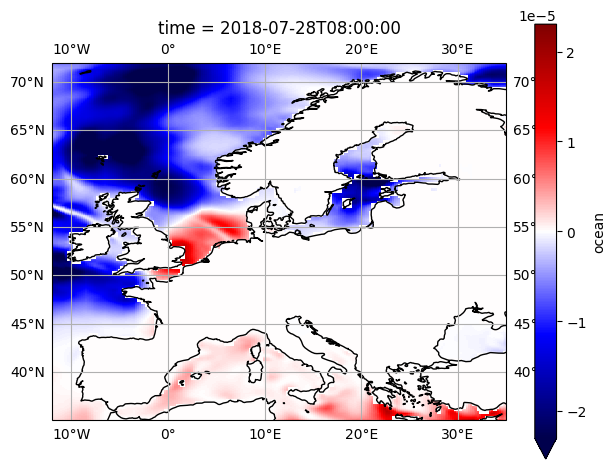

In [10]:
from truncate_colormap import truncate_colormap

ocn_toplot = ocn.isel({"time":5000})
#aoi_subset = [12, 14, 65, 70] 
#ocn_toplot = select_area(aoi_subset, ocn_toplot)
cmap = mpl.colormaps["seismic"]

fig, ax = plt.subplots(subplot_kw=dict(projection=ccrs.PlateCarree()))

ocn_toplot["ocean"].plot.pcolormesh(ax=ax, 
                                      robust=True, cmap=cmap,)
                                       #cbar_kwargs=dict(label=cbar_label, shrink=cbar_shrink))
ax.coastlines()
ax.gridlines(draw_labels=True)
#ax.set_title(suptitle)
plt.tight_layout()
plt.draw()

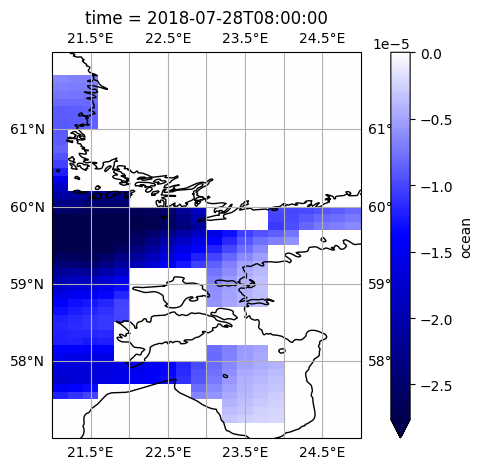

In [13]:
from truncate_colormap import truncate_colormap

ocn_small = ocn.isel({"time":5000})
aoi_subset = [21, 25, 57, 62] 
ocn_small = select_area(aoi_subset, ocn_small)
cmap = truncate_colormap(mpl.colormaps["seismic"], maxval=0.5)

fig, ax = plt.subplots(subplot_kw=dict(projection=ccrs.PlateCarree()))

ocn_small["ocean"].plot.pcolormesh(ax=ax, 
                                      robust=True, cmap=cmap,)
                                       #cbar_kwargs=dict(label=cbar_label, shrink=cbar_shrink))
ax.coastlines()
ax.gridlines(draw_labels=True)
#ax.set_title(suptitle)
plt.tight_layout()
plt.draw()


In [10]:
#interpolate to 0.1 x 0.1 deg resolution 
# and check with land-sea mask that ocean fluxes not on land 



def create_lsm(latmin, latmax, lonmin, lonmax):
     """Creates a land-sea mask (land=1, sea=0) in 0.1 deg x 0.1 deg resolution
     for the chosen area.
     """
     lat = np.linspace(latmin,latmax, int((latmax-latmin)*10+1))#, dtype=np.float32)
     lon = np.linspace(lonmin,lonmax, int((lonmax - lonmin)*10+1))#, dtype=np.float32)
     longrid, latgrid = np.meshgrid(lon,lat)
     lsm = globe.is_land(latgrid, longrid)
   
     return lsm, latgrid, longrid

latmin = 35.05
latmax = 71.95
lonmin = -11.95
lonmax = 34.95

lat = np.linspace(latmin,latmax, int((latmax-latmin)*10+1))
lsm = create_lsm(34.05, 72.95, -14.95, 39.95)



# Naive interpolation
Steps:
1) First bilinear interpolation on the original data
2) Masking out the landcells to zero

In [37]:
def high_res_lon(data):
    lon = data["longitude"].values
    n_lon = len(lon)
    new_lon = np.linspace(lon.min()-0.05, lon.max()+0.05, n_lon * 2)

    return new_lon


def create_lsm_like(data):
    lon = data["longitude"].values
    lat = data["latitude"].values
    longrid, latgrid = np.meshgrid(lon,lat)
    lsm = globe.is_land(latgrid, longrid)
    return lsm


In [ ]:

new_lon = high_res_lon(ocn_small)

small_naive = ocn_small.interp({"longitude" :new_lon})

#set land cells to zero
lsm = create_lsm_like(small_naive)
small_naive["ocean"].values[lsm] = 0

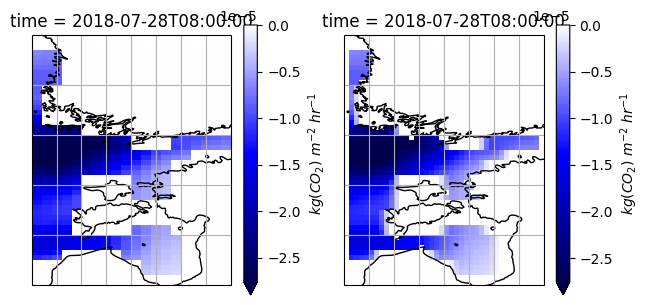

In [15]:

titles = ["orig", "naive"]
datas = [ocn_small, small_naive]
cbar_label= "$kg(CO_2)$ $m^{-2}$ $hr^{-1}$"
cbar_shrink = 0.6
cmap = truncate_colormap(mpl.colormaps["seismic"], maxval=0.5)

fig, axs = plt.subplots(1,2, subplot_kw=dict(projection=ccrs.PlateCarree()))
for i, ax in enumerate(axs.flatten()):
    data = datas[i]
    ax.set_title(titles[i])
    data["ocean"].plot.pcolormesh(ax=ax, 
                                      robust=True, cmap=cmap,
                                       cbar_kwargs=dict(label=cbar_label, shrink=cbar_shrink))
    ax.coastlines()
    ax.gridlines()#draw_labels=True)
#ax.set_title(suptitle)
plt.tight_layout()
plt.draw()

# Try to improve boundary values

* Method: Fill original resolution 0's using linear interpolation
* Then perform naive interpolation to high resolution as before

In [12]:

from scipy.interpolate import griddata

def interpolate_and_replace(dataset, variable_name, method='linear'):
    """
    Replace all 0 values in an xarray dataset's variable with interpolated values 
    based on latitude and longitude, independently for each time step.

    Parameters:
    - dataset: xarray.Dataset
        The original dataset containing the variable to be interpolated.
    - variable_name: str
        The name of the variable to process.
    - method: str, optional
        The interpolation method to use ('linear', 'nearest', or 'cubic').
        Default is 'linear'.

    Returns:
    - new_dataset: xarray.Dataset
        A new dataset with interpolated values replacing zeros.
    """
    # Create a copy of the original dataset
    new_dataset = dataset.copy(deep=True)

    # Extract the variable and its dimensions
    var = new_dataset[variable_name]
    
    # Ensure the dataset has a time dimension
    if 'time' not in var.dims:
        raise ValueError("The dataset does not have a 'time' dimension.")

    # Initialize an empty array to store interpolated data
    interpolated_data = np.empty_like(var.values)

    # Loop over time steps
    for t in range(len(var['time'])):
        # Extract data for the current time step
        var_t = var.isel(time=t)
        lat = new_dataset['latitude']
        lon = new_dataset['longitude']

        # Replace zeros with NaN for interpolation
        var_t_with_nan = var_t.where(var_t != 0, np.nan)

        # Flatten latitude, longitude, and variable values for griddata input
        lon_grid, lat_grid = np.meshgrid(lon, lat)
        points = np.array([lat_grid.ravel(), lon_grid.ravel()]).T
        values = var_t_with_nan.values.ravel()

        # Identify valid points (where the variable is not NaN)
        valid_mask = ~np.isnan(values)
        valid_points = points[valid_mask]
        valid_values = values[valid_mask]

        # Interpolate to fill missing (NaN) values, including extrapolation at boundaries
        interpolated_values = griddata(
            valid_points, valid_values, points, method=method, fill_value=np.nan
        )

        # Reshape interpolated values back to the original grid shape
        interpolated_grid = interpolated_values.reshape(var_t.shape)

        # Replace zeros in the original data with interpolated values
        filled_var = np.where(var_t == 0, interpolated_grid, var_t)

        

        # Assign the interpolated data to the output array
        interpolated_data[t, :, :] = filled_var

    # Update the variable in the new dataset
    new_dataset[variable_name] = (var.dims, interpolated_data)

    return new_dataset



# Test on small area

In [42]:
ocn_small = ocn.isel({"time":5000})
aoi_subset = [21, 25, 57, 62] 
ocn_small = select_area(aoi_subset, ocn_small)
ocn_small_filled = interpolate_and_replace(ocn_small, "ocean")

new_lon = high_res_lon(ocn_small)

naive_filled = ocn_small_filled.interp({"longitude" :new_lon})

#set land cells to zero
lsm = create_lsm_like(naive_filled)
naive_filled["ocean"].values[lsm] = 0

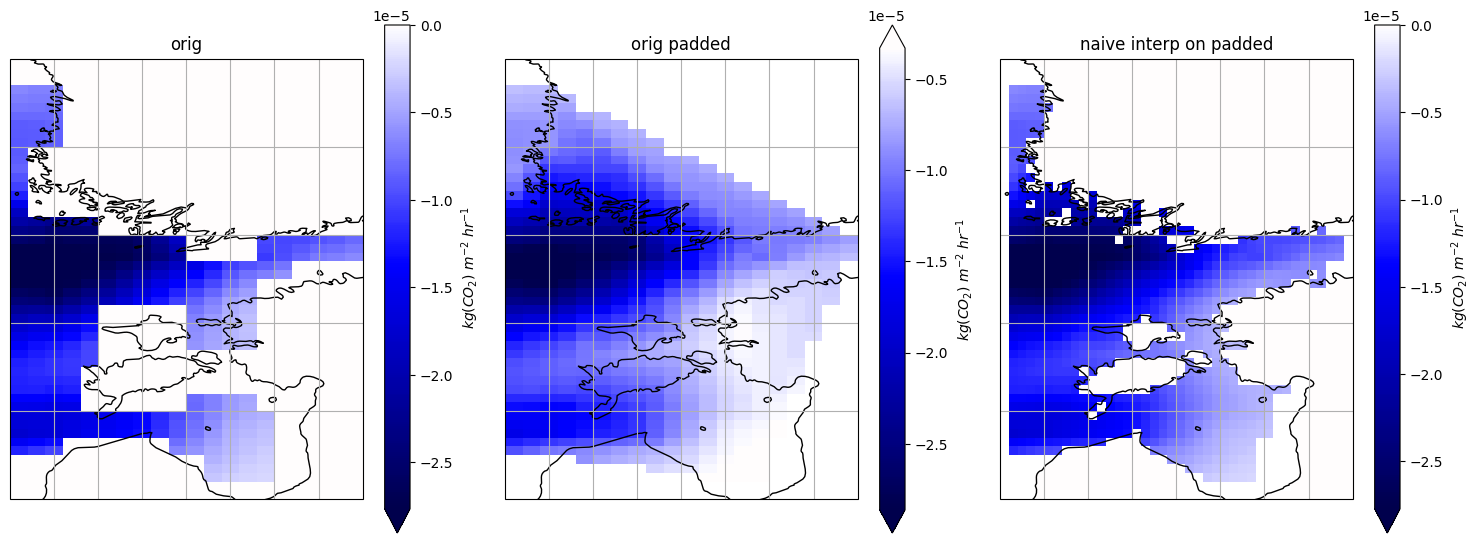

In [43]:
titles = ["orig","orig padded", "naive interp on padded"]
datas = [ocn_small, ocn_small_filled, naive_filled]
cbar_label= "$kg(CO_2)$ $m^{-2}$ $hr^{-1}$"
cbar_shrink = 0.4

fig, axs = plt.subplots(1,3, figsize=(15,13), subplot_kw=dict(projection=ccrs.PlateCarree()))
for i, ax in enumerate(axs.flatten()):
    data = datas[i]
    
    data["ocean"].plot.pcolormesh(ax=ax, 
                                      robust=True, cmap=cmap,
                                       cbar_kwargs=dict(label=cbar_label, shrink=cbar_shrink))
    ax.coastlines()
    ax.gridlines()#draw_labels=True)
    ax.set_title(titles[i])
#ax.set_title(suptitle)
plt.tight_layout()
plt.draw()

# Compute totals

In [9]:
def hourly_kgm2hr_to_gm2yr(ds, var):
    """Unit conversion for hourly time resolution data from unit kg/m2/hr to g/m2/yr"""

    #hourly to yearly
    out = ds[var].sum(dim="time")
    #kg to g
    out = out*1000
    #pick the first timestamp as the time axis value to represent the year
    time = ds["time"].values[0]
    out = out.to_dataset()
    out.coords["time"] = (time) 
    out = out.expand_dims("time")
    return out


# Totals for lower resolution

In [11]:
FLUX_PATH = "/home/pietaril/Documents/data/CTE_ocean_fluxes/domain_-12_35_35_72/coarse_kg_m-2_hr-1/"
YEARLY_PATH = "/home/pietaril/Documents/data/CTE_ocean_fluxes/domain_-12_35_35_72/coarse_g_m-2_yr/"
aoi = [-12, 35, 35, 72]

fnames_1year = [os.path.join(FLUX_PATH,f) for f in os.listdir(FLUX_PATH) if f.endswith(".nc")]
for fname in fnames_1year:
    year = fname[-7:-3]
    ds = xr.open_dataset(fname)
    gm2yr = hourly_kgm2hr_to_gm2yr(ds, "emi_ocn")
    gm2yr.attrs = {}
    gm2yr.attrs.update({"description": "Ocean CO2 gridded total yearly fluxes from CTE-HR with resolution 0.1 x 0.2",
                            "units": "g m-2 yr-1"})

    outname = f"ocean_gridded_yearly_tot_flux_coarse_{year}.nc"

    gm2yr.to_netcdf(os.path.join(YEARLY_PATH, outname), encoding={'time':{'units': "days since 1900-01-01"}})
    

# Totals for data interpolated to higher resolution 

In [15]:
COARSE_PATH = "/home/pietaril/Documents/data/CTE_ocean_fluxes/domain_-12_35_35_72/coarse_kg_m-2_hr-1/"
HIGHRES_PATH = "/home/pietaril/Documents/data/CTE_ocean_fluxes/domain_-12_35_35_72/kg_m-2_hr-1/"
aoi = [-12, 35, 35, 72]

fnames_1year = [os.path.join(FLUX_PATH,f) for f in os.listdir(FLUX_PATH) if f.endswith(".nc")]
ds = xr.open_dataset(fnames_1year[0])



<xarray.Dataset>
Dimensions:    (time: 2, longitude: 235, latitude: 370)
Coordinates:
  * time       (time) datetime64[ns] 2020-01-01 2020-01-01T01:00:00
  * longitude  (longitude) float64 -11.9 -11.7 -11.5 -11.3 ... 34.5 34.7 34.9
  * latitude   (latitude) float64 35.05 35.15 35.25 35.35 ... 71.75 71.85 71.95
Data variables:
    emi_ocn    (time, latitude, longitude) float64 -3.155e-06 ... -2.552e-05
Attributes:
    description:  Ocean CO2 fluxes from CTE-HR with resolution 0.1 x 0.2
    units:        kg m-2 hr-1

# Sanity checks

In [ ]:
#check the function piece by piece

dataset = ocn_small
new_dataset = dataset.copy(deep=True)

# Extract coordinates and the variable
lat = new_dataset['latitude']
lon = new_dataset['longitude']
var = new_dataset["ocean"]

# Replace zeros with NaN for interpolation
var_with_nan = var.where(var != 0, np.nan)

# Flatten latitude, longitude, and variable values for griddata input
lon_grid, lat_grid = np.meshgrid(lon, lat)
points = np.array([lat_grid.ravel(), lon_grid.ravel()]).T
values = var_with_nan.values.ravel()

# Identify valid points (where the variable is not NaN)
valid_mask = ~np.isnan(values)
valid_points = points[valid_mask]
valid_values = values[valid_mask]

# Interpolate to fill missing (NaN) values, including extrapolation at boundaries
interpolated_values = griddata(
    valid_points, valid_values, points, method=method, fill_value=np.nan
)

# Reshape interpolated values back to the original grid shape
interpolated_grid = interpolated_values.reshape(var.shape)

# Replace zeros in the original data with interpolated values
filled_var = np.where(var == 0, interpolated_grid, var)

# Assign the modified variable to the new dataset
new_dataset["ocean"] = (var.dims, filled_var)


# Old attempts at finding coastal cells

In [22]:
ocn_toplot["ocean"].values
lat = ocn_toplot["latitude"].values
lon = ocn_toplot["longitude"].values
n_lon = len(lon)
n_lat = len(lat)
new_lon = np.linspace(lon.min()-0.05, lon.max()+0.05, n_lon * 2)

# Compute the midpoints of the two new grid cells for each original cell
lon_grid = np.tile(lon, (n_lat, 1))  # Create a 2D grid of longitudes
lon1 = lon_grid - 0.05  # Longitudes for the first half of each split cell
lon2 = lon_grid + 0.05  # Longitudes for the second half of each split cell


# Create 2D arrays of latitude and longitude for the land-sea mask
lat_grid = np.repeat(lat[:, np.newaxis], n_lon, axis=1)  # Create a 2D grid of latitudes

# Check land/sea status for both halves of each grid cell
is_land_1 = globe.is_land(lat_grid, lon1)
is_land_2 = globe.is_land(lat_grid, lon2)

# Create a new data array with doubled longitude resolution
new_data = np.zeros((n_lat, n_lon * 2))

# Assign values based on land-sea mask
# First column of each pair (land if applicable)
new_data[:, ::2] = np.where(is_land_1 & ~is_land_2, 1, 0)
# Second column of each pair (sea if applicable)
new_data[:, 1::2] = np.where(is_land_2 & ~is_land_1, 1, 0)



In [29]:
new_data = xr.DataArray(new_data, coords= [lat, new_lon], dims = ["latitude", "longitude"] )
new_data


<xarray.DataArray (latitude: 370, longitude: 470)>
array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])
Coordinates:
  * latitude   (latitude) float64 35.05 35.15 35.25 35.35 ... 71.75 71.85 71.95
  * longitude  (longitude) float64 -11.95 -11.85 -11.75 ... 34.75 34.85 34.95

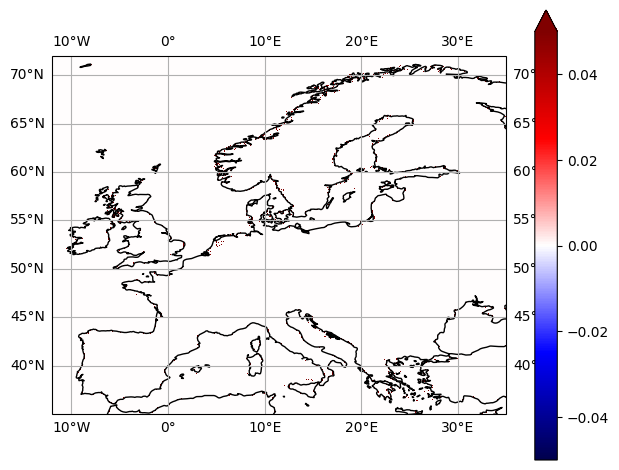

In [30]:
fig, ax = plt.subplots(subplot_kw=dict(projection=ccrs.PlateCarree()))

new_data.plot.pcolormesh(ax=ax, robust=True, cmap=cmap,)
                                       #cbar_kwargs=dict(label=cbar_label, shrink=cbar_shrink))
ax.coastlines()
ax.gridlines(draw_labels=True)
#ax.set_title(suptitle)
plt.tight_layout()
plt.draw()

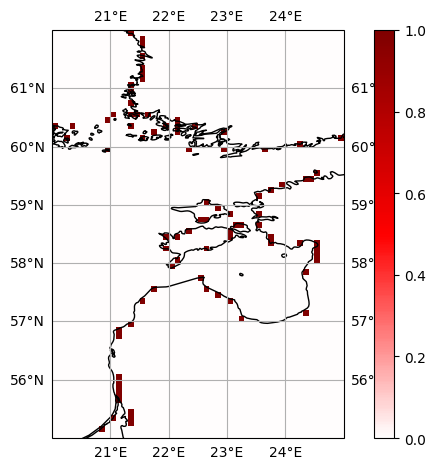

In [32]:
new_data_subset = select_area(aoi_subset, new_data)

fig, ax = plt.subplots(subplot_kw=dict(projection=ccrs.PlateCarree()))
cmap = truncate_colormap(mpl.colormaps["seismic"], minval = 0.5)
new_data_subset.plot.pcolormesh(ax=ax, robust=True, cmap=cmap,)
                                       #cbar_kwargs=dict(label=cbar_label, shrink=cbar_shrink))
ax.coastlines()
ax.gridlines(draw_labels=True)
#ax.set_title(suptitle)
plt.tight_layout()
plt.draw()

In [10]:


def assign_coastal_cells_vectorized(data, lon, lat):
    """
    Vectorized version of splitting grid cells along the coastline into land and sea components.

    Parameters:
    - data: 2D numpy array of shape (n_lat, n_lon) with flux values.
    - lon: 1D numpy array of longitudes corresponding to the original grid.
    - lat: 1D numpy array of latitudes corresponding to the original grid.

    Returns:
    - new_data: 2D numpy array with flux values at 0.1° x 0.1° resolution.
    - new_lon: 1D numpy array of new longitudes.
    - lat: 1D numpy array of latitudes (unchanged).
    """
    n_lat, n_lon = data.shape

    # Create the new longitude array with doubled resolution
    new_lon = np.linspace(lon.min()-0.05, lon.max()+0.05, n_lon * 2)

    # Compute the midpoints of the two new grid cells for each original cell
    lon_grid = np.tile(lon, (n_lat, 1))  # Create a 2D grid of longitudes
    lon1 = lon_grid - 0.05  # Longitudes for the first half of each split cell
    lon2 = lon_grid + 0.05  # Longitudes for the second half of each split cell

    # Create 2D arrays of latitude and longitude for the land-sea mask
    lat_grid = np.repeat(lat[:, np.newaxis], n_lon, axis=1)  # Create a 2D grid of latitudes

    # Check land/sea status for both halves of each grid cell
    is_land_1 = globe.is_land(lat_grid, lon1)
    is_land_2 = globe.is_land(lat_grid, lon2)

    # Create a new data array with doubled longitude resolution
    new_data = np.zeros((n_lat, n_lon * 2))

    # Assign values based on land-sea mask
    # First column of each pair (land if applicable)
    new_data[:, ::2] = np.where(is_land_1 & ~is_land_2, 0, data)
    # Second column of each pair (sea if applicable)
    new_data[:, 1::2] = np.where(is_land_2 & ~is_land_1, 0, data)

    return new_data, new_lon, lat



<xarray.Dataset>
Dimensions:    (time: 8760, longitude: 250, latitude: 380)
Coordinates:
  * time       (time) datetime64[ns] 2018-01-01 ... 2018-12-31T23:00:00
  * longitude  (longitude) float64 -14.9 -14.7 -14.5 -14.3 ... 34.5 34.7 34.9
  * latitude   (latitude) float64 34.05 34.15 34.25 34.35 ... 71.75 71.85 71.95
Data variables:
    ocean      (time, latitude, longitude) float32 -5.065e-08 ... -7.527e-09
Attributes: (12/19)
    CDI:                        Climate Data Interface version 1.9.9 (https:/...
    Conventions:                CF-1.8
    URL:                        http://carbontracker.wur.nl
    disclaimer:                 This data belongs to the CarbonTracker project
    CDO:                        Climate Data Operators version 1.9.9 (https:/...
    source:                     CTE-HR 1.0. Created using the code from https...
    ...                         ...
    geospatial_lat_resolution:  0.1 degree
    geospatial_lon_resolution:  0.2 degree
    keywords:                   carbon flux
    license:                    CC-BY-4.0
    nominal_resolution:         0.1x0.2 degree
    comment:                    Hourly ocean fluxes, based on a climatology o...

In [ ]:
    
ds_out.attrs.update({"description": ""})



# Write the output dataset to a new NetCDF file
ds_out.to_netcdf(output_file, encoding={'time':{'units': "days since 1900-01-01"}})
